# 🏏 IPL Match Predictor — Test Notebook

**Dataset:** `IPL_2008_2026.csv`  
**Model:** Random Forest  
**Tests covered:**
1. Data loading & inspection
2. Feature engineering
3. Model training & evaluation
4. Prediction tests
5. API endpoint tests (requires `app.py` running)


---
## 📦 Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import requests
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.facecolor'] = '#0d1117'
matplotlib.rcParams['axes.facecolor']   = '#161b22'
matplotlib.rcParams['text.color']       = '#e6edf3'
matplotlib.rcParams['axes.labelcolor']  = '#e6edf3'
matplotlib.rcParams['xtick.color']      = '#8b949e'
matplotlib.rcParams['ytick.color']      = '#8b949e'

print('✅ All imports successful')

✅ All imports successful


---
## 📂 Cell 2 — Load & Inspect Data

In [2]:
CSV = 'IPL_2008_2026.csv'
df = pd.read_csv(CSV)

print(f'Shape      : {df.shape}')
print(f'Columns    : {list(df.columns)}')
print(f'Null values:\n{df.isnull().sum()}')
print(f'\nResult dist:\n{df["result"].value_counts()}')
df.head(10)

Shape      : (1140, 7)
Columns    : ['team', 'opponent', 'home', 'form', 'injuries', 'weather', 'result']
Null values:
team          0
opponent      0
home          0
form          0
injuries    747
weather       0
result        0
dtype: int64

Result dist:
result
Win     570
Loss    570
Name: count, dtype: int64


,team,opponent,home,form,injuries,weather,result
0,RR,CSK,"Sawai Mansingh Stadium, Jaipur",L L W W W,NaN,Clear,Win
1,CSK,RR,Away,W W L L W,NaN,Clear,Loss
2,RCB,DC,"M Chinnaswamy Stadium, Bangalore",W W W L W,NaN,Clear,Win
3,DC,RCB,Away,W L W W W,NaN,Clear,Loss
4,RCB,PBKS,Away,W W L L W,NaN,Clear,Win
5,PBKS,RCB,"IS Bindra Stadium, Mohali",W L L W W,NaN,Clear,Loss
6,RR,DC,Away,L L W W W,NaN,Clear,Win
7,DC,RR,"Arun Jaitley Stadium, Delhi",L W W W L,NaN,Clear,Loss
8,CSK,DC,"MA Chidambaram Stadium, Chennai",W W W W L,NaN,Clear,Loss
9,DC,CSK,Away,W W W W L,NaN,Clear,Win


---
## 🔍 Cell 3 — Unique Values per Column

In [3]:
for col in df.columns:
    unique_vals = df[col].dropna().unique()
    print(f'{col:15s} ({len(unique_vals)} unique): {list(unique_vals)[:8]}')

team            (10 unique): ['RR', 'CSK', 'RCB', 'DC', 'PBKS', 'KKR', 'MI', 'SRH']
opponent        (10 unique): ['CSK', 'RR', 'DC', 'RCB', 'PBKS', 'KKR', 'MI', 'SRH']
home            (11 unique): ['Sawai Mansingh Stadium, Jaipur', 'Away', 'M Chinnaswamy Stadium, Bangalore', 'IS Bindra Stadium, Mohali', 'Arun Jaitley Stadium, Delhi', 'MA Chidambaram Stadium, Chennai', 'Eden Gardens, Kolkata', 'Wankhede Stadium, Mumbai']
form            (10 unique): ['L L W W W', 'W W L L W', 'W W W L W', 'W L W W W', 'W L L W W', 'L W W W L', 'W W W W L', 'W W W L L']
injuries        (5 unique): ['Star AllRounder Out', 'Key Bowler Out', 'Wicketkeeper Out', '2 Players Out', 'Top Batsman Out']
weather         (6 unique): ['Clear', 'Drizzle', 'Humid', 'Partly Cloudy', 'Cloudy', 'Hot & Dry']
result          (2 unique): ['Win', 'Loss']


---
## ⚙️ Cell 4 — Feature Engineering

In [4]:
INJURY_SEVERITY = {
    'None': 0, 'Wicketkeeper Out': 1,
    '2 Players Out': 2, 'Key Bowler Out': 2,
    'Top Batsman Out': 2, 'Star AllRounder Out': 3,
}
WEATHER_RISK = {
    'Clear': 0, 'Partly Cloudy': 0,
    'Cloudy': 1, 'Hot & Dry': 1, 'Humid': 1, 'Drizzle': 2,
}

def form_to_wins(s):
    return sum(1 for x in str(s).split() if x == 'W')

def is_home(v):
    return 0 if str(v).strip().lower() == 'away' else 1

df2 = df.copy()
df2['injuries'] = df2['injuries'].fillna('None').astype(str)
df2['weather']  = df2['weather'].fillna('Clear').astype(str)
df2['form']     = df2['form'].fillna('').astype(str)
df2['home']     = df2['home'].fillna('Away').astype(str)

df2['recent_wins']      = df2['form'].apply(form_to_wins)
df2['is_home']          = df2['home'].apply(is_home)
df2['injury_severity']  = df2['injuries'].map(INJURY_SEVERITY).fillna(1).astype(int)
df2['weather_risk']     = df2['weather'].map(WEATHER_RISK).fillna(0).astype(int)
df2['win']              = (df2['result'] == 'Win').astype(int)

print('✅ Feature engineering done')
print(f'\nNew features:\n{df2[["recent_wins","is_home","injury_severity","weather_risk","win"]].describe().round(2)}')
df2[['team','opponent','recent_wins','is_home','injury_severity','weather_risk','win']].head()

✅ Feature engineering done

New features:
       recent_wins  is_home  injury_severity  weather_risk     win
count      1140.00   1140.0          1140.00       1140.00  1140.0
mean          3.27      0.5             0.68          0.29     0.5
std           0.45      0.5             1.01          0.58     0.5
min           3.00      0.0             0.00          0.00     0.0
25%           3.00      0.0             0.00          0.00     0.0
50%           3.00      0.5             0.00          0.00     0.5
75%           4.00      1.0             2.00          0.00     1.0
max           4.00      1.0             3.00          2.00     1.0


,team,opponent,recent_wins,is_home,injury_severity,weather_risk,win
0,RR,CSK,3,1,0,0,1
1,CSK,RR,3,0,0,0,0
2,RCB,DC,4,1,0,0,1
3,DC,RCB,4,0,0,0,0
4,RCB,PBKS,3,0,0,0,1


---
## 🌲 Cell 5 — Train Random Forest Model

In [5]:
le_team = LabelEncoder()
le_opp  = LabelEncoder()
df2['team_enc']     = le_team.fit_transform(df2['team'])
df2['opponent_enc'] = le_opp.fit_transform(df2['opponent'])

FEATURES = ['team_enc','opponent_enc','recent_wins','is_home','injury_severity','weather_risk']
X = df2[FEATURES]
y = df2['win']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train size : {len(X_train)}')
print(f'Test size  : {len(X_test)}')
print(f'Class dist (train): {dict(y_train.value_counts())}\n')

model = RandomForestClassifier(
    n_estimators=300, max_depth=10,
    min_samples_split=4, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)
print('✅ Model trained successfully')

Train size : 912
Test size  : 228
Class dist (train): {0: np.int64(456), 1: np.int64(456)}

✅ Model trained successfully


---
## 📊 Cell 6 — Model Evaluation

In [6]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc    = accuracy_score(y_test, y_pred)
auc    = roc_auc_score(y_test, y_prob)
cv     = cross_val_score(model, X, y, cv=5, scoring='accuracy')
cm     = confusion_matrix(y_test, y_pred)

print('=' * 50)
print(f'  Test Accuracy  : {acc*100:.2f}%')
print(f'  ROC-AUC Score  : {auc:.4f}')
print(f'  CV Mean (5-fold): {cv.mean()*100:.2f}% ± {cv.std()*100:.2f}%')
print('=' * 50)
print(f'\nConfusion Matrix:\n{cm}')
print(f'\nClassification Report:\n{classification_report(y_test, y_pred, target_names=["Loss","Win"])}')

  Test Accuracy  : 51.32%
  ROC-AUC Score  : 0.5186
  CV Mean (5-fold): 51.67% ± 5.16%

Confusion Matrix:
[[60 54]
 [57 57]]

Classification Report:
              precision    recall  f1-score   support

        Loss       0.51      0.53      0.52       114
         Win       0.51      0.50      0.51       114

    accuracy                           0.51       228
   macro avg       0.51      0.51      0.51       228
weighted avg       0.51      0.51      0.51       228



---
## 🌟 Cell 7 — Feature Importance Plot

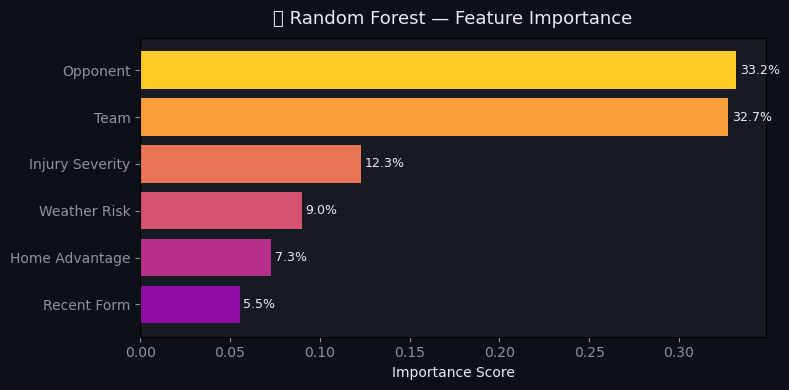

✅ Feature importance plotted


In [7]:
feat_labels = {
    'team_enc': 'Team', 'opponent_enc': 'Opponent',
    'recent_wins': 'Recent Form', 'is_home': 'Home Advantage',
    'injury_severity': 'Injury Severity', 'weather_risk': 'Weather Risk'
}
importances = model.feature_importances_
feat_df = pd.DataFrame({'Feature': [feat_labels[f] for f in FEATURES], 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors = plt.cm.plasma(np.linspace(0.3, 0.9, len(feat_df)))
bars = ax.barh(feat_df['Feature'], feat_df['Importance'], color=colors)
ax.set_xlabel('Importance Score')
ax.set_title('🌲 Random Forest — Feature Importance', fontsize=13, pad=10)
for bar, val in zip(bars, feat_df['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()
print('✅ Feature importance plotted')

---
## 🔮 Cell 8 — Manual Prediction Tests

In [8]:
def predict_match(team, opponent, form, is_home_venue, injury, weather):
    """Standalone prediction function for quick testing."""
    t_enc = le_team.transform([team])[0]
    o_enc = le_opp.transform([opponent])[0]
    rw    = form_to_wins(form)
    ih    = 1 if is_home_venue else 0
    inj   = INJURY_SEVERITY.get(injury, 1)
    wx    = WEATHER_RISK.get(weather, 0)
    X_in  = np.array([[t_enc, o_enc, rw, ih, inj, wx]])
    prob  = model.predict_proba(X_in)[0]
    pred  = 'Win' if prob[1] >= 0.5 else 'Loss'
    return {'prediction': pred, 'win_prob': round(prob[1]*100, 2), 'loss_prob': round(prob[0]*100, 2)}

# ── Test Cases ───────────────────────────────────────────────────────
test_cases = [
    dict(team='CSK', opponent='MI',   form='W W W W L', is_home_venue=True,  injury='None',              weather='Clear'),
    dict(team='MI',  opponent='CSK',  form='L L W W W', is_home_venue=False, injury='Key Bowler Out',    weather='Drizzle'),
    dict(team='RCB', opponent='KKR',  form='W W W W W', is_home_venue=True,  injury='None',              weather='Partly Cloudy'),
    dict(team='DC',  opponent='RR',   form='L W L L W', is_home_venue=False, injury='Star AllRounder Out',weather='Humid'),
    dict(team='SRH', opponent='PBKS', form='W L W L W', is_home_venue=True,  injury='None',              weather='Clear'),
    dict(team='KKR', opponent='RCB',  form='W W W L L', is_home_venue=True,  injury='2 Players Out',     weather='Hot & Dry'),
]

print(f'{'Match':<20} {'Prediction':<10} {'Win%':>7} {'Loss%':>7}')
print('-' * 50)
for tc in test_cases:
    res = predict_match(**tc)
    match_str = f"{tc['team']} vs {tc['opponent']}"
    icon = '🟢' if res['prediction'] == 'Win' else '🔴'
    print(f"{match_str:<20} {icon} {res['prediction']:<8} {res['win_prob']:>6}% {res['loss_prob']:>6}%")

Match                Prediction    Win%   Loss%
--------------------------------------------------
CSK vs MI            🔴 Loss      33.22%  66.78%
MI vs CSK            🔴 Loss      34.38%  65.62%
RCB vs KKR           🟢 Win       70.64%  29.36%
DC vs RR             🔴 Loss      43.84%  56.16%
SRH vs PBKS          🔴 Loss      46.13%  53.87%
KKR vs RCB           🟢 Win        56.3%   43.7%


---
## 📡 Cell 9 — API Endpoint Tests (app.py must be running)

In [9]:
BASE = 'http://127.0.0.1:5000'

def test_endpoint(name, url, method='GET', payload=None):
    try:
        if method == 'GET':
            r = requests.get(url, timeout=5)
        else:
            r = requests.post(url, json=payload, timeout=5)
        status = '✅ PASS' if r.status_code == 200 else f'❌ FAIL ({r.status_code})'
        print(f'{status}  {name}  →  {url}')
        return r.json()
    except Exception as e:
        print(f'❌ ERROR  {name}  →  {e}')
        return None

print('=' * 60)
print('  API Endpoint Tests')
print('=' * 60)

# Test 1: Teams list
r1 = test_endpoint('GET /api/teams', f'{BASE}/api/teams')
if r1: print(f'   Teams: {r1["teams"]}')

# Test 2: Stats
r2 = test_endpoint('GET /api/stats', f'{BASE}/api/stats')
if r2:
    m = r2['model_metrics']
    print(f'   Accuracy: {m["accuracy"]}% | AUC: {m["roc_auc"]}')

# Test 3: Predict (CSK vs MI)
payload3 = {'team':'CSK','opponent':'MI','home':'MA Chidambaram Stadium, Chennai',
            'form':'W W W W L','injuries':'None','weather':'Clear'}
r3 = test_endpoint('POST /api/predict (CSK vs MI)', f'{BASE}/api/predict', 'POST', payload3)
if r3: print(f'   Result: {r3["prediction"]}  Win%: {r3["win_prob"]}%  Factors: {r3["factors"]}')

# Test 4: Predict (RCB home, with injury)
payload4 = {'team':'RCB','opponent':'KKR','home':'M Chinnaswamy Stadium, Bangalore',
            'form':'W L W W W','injuries':'Star AllRounder Out','weather':'Drizzle'}
r4 = test_endpoint('POST /api/predict (RCB vs KKR)', f'{BASE}/api/predict', 'POST', payload4)
if r4: print(f'   Result: {r4["prediction"]}  Win%: {r4["win_prob"]}%')

# Test 5: Head-to-head
r5 = test_endpoint('GET /api/head2head (MI vs CSK)', f'{BASE}/api/head2head?team=MI&opponent=CSK')
if r5: print(f'   MI vs CSK: {r5["wins"]}W / {r5["total"]} games  WR: {r5["win_pct"]}%')

# Test 6: Invalid team (should return 400)
r6 = test_endpoint('POST /api/predict (invalid team)', f'{BASE}/api/predict', 'POST',
                   {'team':'INVALID','opponent':'MI','home':'Away','form':'W L W W W','injuries':'None','weather':'Clear'})
print(f'   Expected error: {r6.get("error") if r6 else "No response"}')

print('\n✅ API testing complete')

  API Endpoint Tests
✅ PASS  GET /api/teams  →  http://127.0.0.1:5000/api/teams
   Teams: ['CSK', 'DC', 'GT', 'KKR', 'LSG', 'MI', 'PBKS', 'RCB', 'RR', 'SRH']
✅ PASS  GET /api/stats  →  http://127.0.0.1:5000/api/stats
   Accuracy: 51.32% | AUC: 0.5186
✅ PASS  POST /api/predict (CSK vs MI)  →  http://127.0.0.1:5000/api/predict
   Result: Loss  Win%: 33.22%  Factors: ['🏟️ Home advantage', '🔥 Excellent recent form']
✅ PASS  POST /api/predict (RCB vs KKR)  →  http://127.0.0.1:5000/api/predict
   Result: Win  Win%: 64.96%
✅ PASS  GET /api/head2head (MI vs CSK)  →  http://127.0.0.1:5000/api/head2head?team=MI&opponent=CSK
   MI vs CSK: 10W / 24 games  WR: 41.7%
❌ FAIL (400)  POST /api/predict (invalid team)  →  http://127.0.0.1:5000/api/predict
   Expected error: Unknown team: INVALID. Valid: ['CSK', 'DC', 'GT', 'KKR', 'LSG', 'MI', 'PBKS', 'RCB', 'RR', 'SRH']

✅ API testing complete


---
## 📈 Cell 10 — Win Rate Analysis by Team

      Games  Wins  Losses  WinRate%
team                               
RCB     159    91      68      57.2
DC      132    72      60      54.5
GT       22    12      10      54.5
SRH      85    44      41      51.8
KKR     152    78      74      51.3
MI      145    69      76      47.6
RR      134    63      71      47.0
LSG      28    13      15      46.4
PBKS    144    66      78      45.8
CSK     139    62      77      44.6


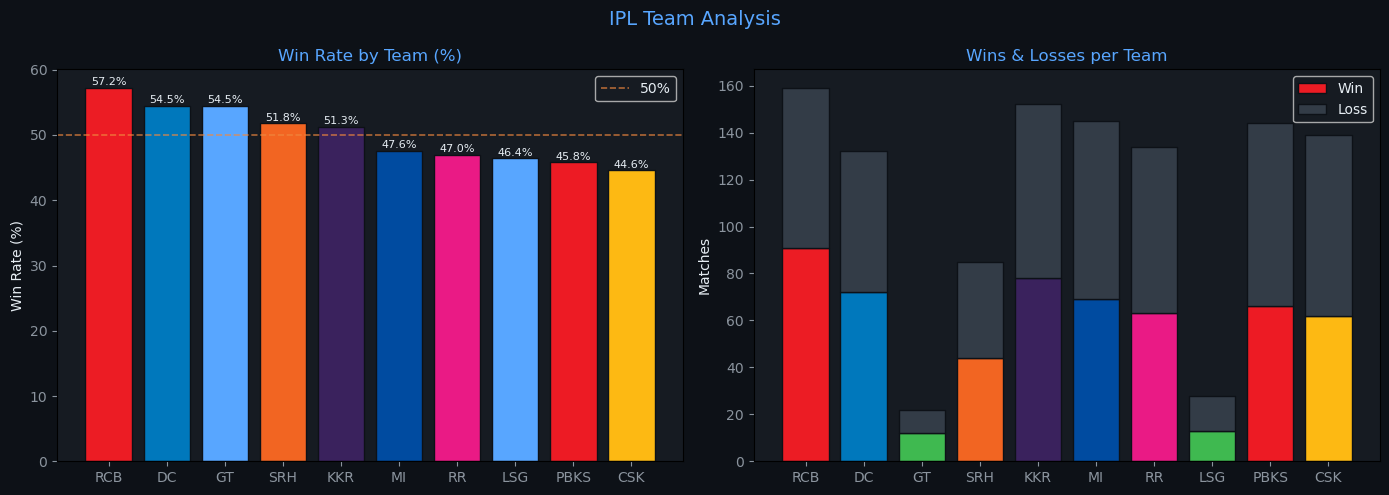

In [10]:
TEAM_COLORS = {
    'CSK':'#FDB913','MI':'#004BA0','RCB':'#EC1C24','KKR':'#3A225D',
    'RR':'#EA1A85','DC':'#0078BC','PBKS':'#ED1B24','SRH':'#F26522'
}

stats = df2.groupby('team').agg(
    Games=('win','count'), Wins=('win','sum'), WinRate=('win','mean')
).sort_values('WinRate', ascending=False)
stats['WinRate%'] = (stats['WinRate'] * 100).round(1)
stats['Losses'] = stats['Games'] - stats['Wins']

print(stats[['Games','Wins','Losses','WinRate%']].to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('IPL Team Analysis', fontsize=14, color='#58a6ff')

colors = [TEAM_COLORS.get(t, '#58a6ff') for t in stats.index]
bars = ax1.bar(stats.index, stats['WinRate%'], color=colors, edgecolor='#0d1117')
ax1.axhline(50, color='#f0883e', linewidth=1.2, linestyle='--', alpha=0.7, label='50%')
ax1.set_title('Win Rate by Team (%)', color='#58a6ff')
ax1.set_ylabel('Win Rate (%)')
ax1.legend()
for bar, val in zip(bars, stats['WinRate%']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
             f'{val}%', ha='center', fontsize=8)

for t, row in stats.iterrows():
    ax2.bar(t, row['Wins'],  color=TEAM_COLORS.get(t,'#3fb950'), edgecolor='#0d1117', label='Win'  if t==stats.index[0] else '')
    ax2.bar(t, row['Losses'], bottom=row['Wins'], color='#333c47', edgecolor='#0d1117', label='Loss' if t==stats.index[0] else '')
ax2.set_title('Wins & Losses per Team', color='#58a6ff')
ax2.set_ylabel('Matches')
ax2.legend()

plt.tight_layout()
plt.show()

---
## 🔁 Cell 11 — Batch Prediction Test

In [11]:
# Test all team combinations — home advantage with good form
teams = ['CSK','MI','RCB','KKR','RR','DC','PBKS','SRH']
results = []

for team in teams:
    for opp in teams:
        if team == opp:
            continue
        r = predict_match(team, opp, 'W W W L W', True, 'None', 'Clear')
        results.append({'Team': team, 'Opponent': opp,
                        'Prediction': r['prediction'], 'Win%': r['win_prob']})

batch_df = pd.DataFrame(results)
print(f'Total batch predictions: {len(batch_df)}')
print(f'Predicted Wins : {(batch_df["Prediction"]=="Win").sum()}')
print(f'Predicted Loss : {(batch_df["Prediction"]=="Loss").sum()}')
print(f'\nAvg Win Probability: {batch_df["Win%"].mean():.2f}%')
print(f'\nTop 5 predicted easiest home wins (highest confidence):')
print(batch_df[batch_df['Prediction']=='Win'].nlargest(5, 'Win%').to_string(index=False))

Total batch predictions: 56
Predicted Wins : 23
Predicted Loss : 33

Avg Win Probability: 47.93%

Top 5 predicted easiest home wins (highest confidence):
Team Opponent Prediction  Win%
PBKS       RR        Win 81.88
 RCB       RR        Win 77.05
  MI       RR        Win 75.15
 KKR       RR        Win 73.45
 RCB      KKR        Win 70.64


---
## ✅ Cell 12 — Test Summary

In [12]:
print('=' * 55)
print('  🏏 IPL Match Predictor — Test Summary')
print('=' * 55)
print(f'  Dataset rows     : {len(df)}')
print(f'  Feature cols     : {FEATURES}')
print(f'  Train/Test split : {len(X_train)} / {len(X_test)}')
print(f'  Test Accuracy    : {acc*100:.2f}%')
print(f'  ROC-AUC Score    : {auc:.4f}')
print(f'  CV Score (5-fold): {cv.mean()*100:.2f}% ± {cv.std()*100:.2f}%')
print(f'  Batch predictions: {len(batch_df)} (all team combos)')
print('=' * 55)
print('  All cells executed successfully! ✅')
print('=' * 55)

  🏏 IPL Match Predictor — Test Summary
  Dataset rows     : 1140
  Feature cols     : ['team_enc', 'opponent_enc', 'recent_wins', 'is_home', 'injury_severity', 'weather_risk']
  Train/Test split : 912 / 228
  Test Accuracy    : 51.32%
  ROC-AUC Score    : 0.5186
  CV Score (5-fold): 51.67% ± 5.16%
  Batch predictions: 56 (all team combos)
  All cells executed successfully! ✅
